Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

[OPTIMIZER] epoch_start=0 global_step=0 wrapped=AcceleratedOptimizer base=AdamW lr=0.0 id=137453703240624 hyperparams={'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 3e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 3e-05}
[SCHEDULER]   scheduler_last_lr=[0.0]
[PARAMS]   params_total=129,137,667 params_trainable=129,137,667


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro,Mse,Sse
1,2.036000,0.470350,0.856667,0.856823,0.857425,0.856667,0.083447,25.034182
2,0.458700,0.260683,0.916667,0.916896,0.917513,0.916667,0.044186,13.255908
3,0.229900,0.257767,0.916667,0.916761,0.916977,0.916667,0.044627,13.388020
4,0.133600,0.258026,0.906667,0.906593,0.906640,0.906667,0.045069,13.520815


[TRAINING_PERFORMANCE] epoch=1.0 tokens=0 time=25.30s tok/s=0.0 ex/s=0.00 peak_mem=2.60GiB lr=2.39e-05
[EVALUATION_PERFORMANCE] tokens=81920 time=0.52s tok/s=158546.8 ex/s=1238.65
[EVALUATION_PERFORMANCE] accuracy=0.8567 cost=$0.01 accuracy_per_$=57.86
[OPTIMIZER] epoch_start=1.0 global_step=75 wrapped=AcceleratedOptimizer base=AdamW lr=2.3936170212765956e-05 id=137453703240624 hyperparams={'lr': 2.3936170212765956e-05, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 3e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 2.3936170212765956e-05, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 3e-05}
[SCHEDULER]   scheduler_last_lr=[2.3936170212765956e-05]
[PARAMS] 

[EVALUATION_PERFORMANCE] tokens=81920 time=0.63s tok/s=129159.8 ex/s=1009.06
[EVALUATION_PERFORMANCE] accuracy=0.9300 cost=$0.10 accuracy_per_$=9.36

### STATE-SPACES/MAMBA-130M-HF EVALUATION METRICS ###
{'epoch': 4.0,
 'eval_accuracy': 0.93,
 'eval_f1_macro': 0.9296363521184562,
 'eval_loss': 0.2247314453125,
 'eval_mse': 0.039695522424733475,
 'eval_precision_macro': 0.9311795802636583,
 'eval_recall_macro': 0.93,
 'eval_runtime': 0.7003,
 'eval_samples_per_second': 428.366,
 'eval_sse': 11.908656727420043,
 'eval_steps_per_second': 7.139}


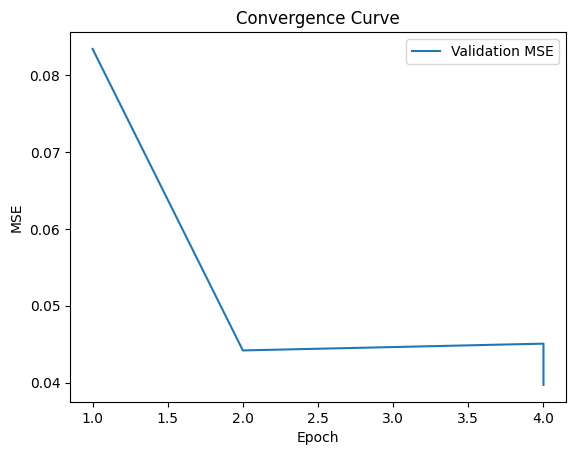

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2400 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

In [1]:
# A State Space Model Approach to Cross-Lingual Sentiment Analysis of Filipino Texts 


import os
import pandas as pd
import pprint

from pathlib import Path
from transformers import pipeline

from src.config import *
from src.metrics import evaluate_pipe
from src import (
    context,
    helper,
    sentiment, 
    utility, 
)

os.environ["HF_DATASETS_DISABLE_CACHING"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
helper.list_config()

if App.HAS_GPU:
    os.environ["MAMBA_USE_MAMBAPY"] = Mamba.FORCE_CUDA
    os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

if App.ACTION == "TRAIN":
    mamba_context = context.setup_pipeline(Mamba, require_translation = False)
    mamba_trainer = sentiment.train(mamba_context)

